In [1]:
from pathlib import Path
import sys

root = Path.cwd()
while not (root / "pyproject.toml").exists() and root != root.parent:
    root = root.parent

%cd {root}

!{sys.executable} -m monitoring.run_drift --limit 2000 --ref-csv data/reference/reference_sample.csv


c:\Users\thoma\Documents\Openclassroom\Projet-8
✅ Drift report written to: C:\Users\thoma\Documents\Openclassroom\Projet-8\outputs\monitoring\drift_report.json


Status: critical
Warnings: 747 Critical: 817


,severity,kind,feature,value,threshold,message
0,critical,psi,AMT_ANNUITY,12.410110,0.25,PSI élevé sur AMT_ANNUITY: 12.410
1,critical,psi,AMT_CREDIT,12.434727,0.25,PSI élevé sur AMT_CREDIT: 12.435
2,critical,psi,AMT_GOODS_PRICE,12.075738,0.25,PSI élevé sur AMT_GOODS_PRICE: 12.076
3,critical,psi,AMT_INCOME_TOTAL,12.479489,0.25,PSI élevé sur AMT_INCOME_TOTAL: 12.479
4,critical,psi,AMT_REQ_CREDIT_BUREAU_DAY,1.875871,0.25,PSI élevé sur AMT_REQ_CREDIT_BUREAU_DAY: 1.876
5,critical,psi,AMT_REQ_CREDIT_BUREAU_HOUR,1.875871,0.25,PSI élevé sur AMT_REQ_CREDIT_BUREAU_HOUR: 1.876
6,critical,psi,AMT_REQ_CREDIT_BUREAU_MON,1.875871,0.25,PSI élevé sur AMT_REQ_CREDIT_BUREAU_MON: 1.876
7,critical,psi,AMT_REQ_CREDIT_BUREAU_QRT,1.948718,0.25,PSI élevé sur AMT_REQ_CREDIT_BUREAU_QRT: 1.949
8,critical,psi,AMT_REQ_CREDIT_BUREAU_WEEK,1.875871,0.25,PSI élevé sur AMT_REQ_CREDIT_BUREAU_WEEK: 1.876
9,critical,psi,AMT_REQ_CREDIT_BUREAU_YEAR,6.491593,0.25,PSI élevé sur AMT_REQ_CREDIT_BUREAU_YEAR: 6.492


,feature,psi
483,ORGANIZATION_TYPE_Legal Services,27.630993
479,ORGANIZATION_TYPE_Industry: type 8,27.630993
469,ORGANIZATION_TYPE_Industry: type 10,27.630993
503,ORGANIZATION_TYPE_Trade: type 5,27.630993
498,ORGANIZATION_TYPE_Telecom,27.630993
490,ORGANIZATION_TYPE_Realtor,27.630993
486,ORGANIZATION_TYPE_Mobile,27.630993
481,ORGANIZATION_TYPE_Insurance,27.630993
472,ORGANIZATION_TYPE_Industry: type 13,27.630993
325,FLAG_DOCUMENT_7,27.630993


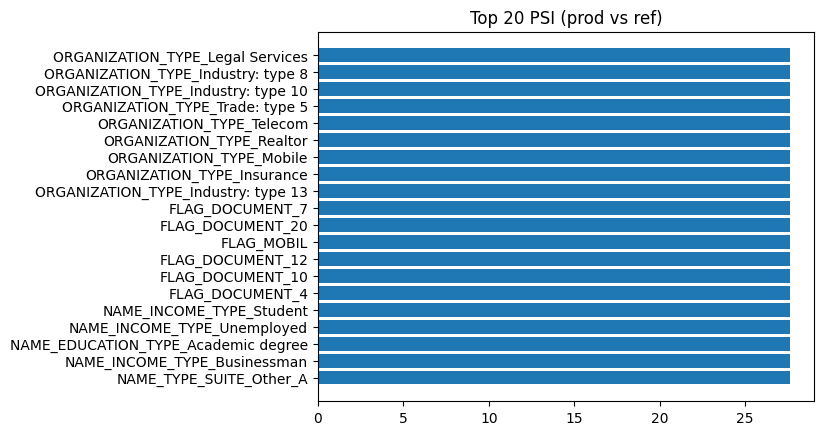

,feature,missing_rate_delta,ref_missing_rate,prod_missing_rate
805,TARGET,1.0,0.0,1.0
803,REG_REGION_NOT_WORK_REGION,1.0,0.0,1.0
310,FLAG_DOCUMENT_12,1.0,0.0,1.0
309,FLAG_DOCUMENT_11,1.0,0.0,1.0
308,FLAG_DOCUMENT_10,1.0,0.0,1.0
307,FLAG_CONT_MOBILE,1.0,0.0,1.0
300,EMERGENCYSTATE_MODE_Yes,1.0,0.0,1.0
506,ORGANIZATION_TYPE_Transport: type 1,1.0,0.0,1.0
505,ORGANIZATION_TYPE_Trade: type 7,1.0,0.0,1.0
504,ORGANIZATION_TYPE_Trade: type 6,1.0,0.0,1.0


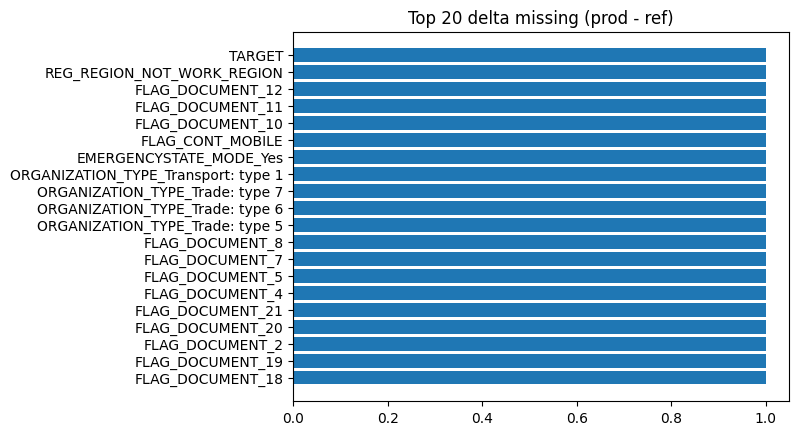

Prod rows: 2000 Distinct rows: 1
Prod meta: {'parse_errors': 0, 'read_rows': 2000, 'ts_min': '2026-02-10T23:57:01.476017+00:00', 'ts_max': '2026-02-10T23:57:07.396183+00:00'}
Filled ratio (mean): 0.409252669039146 min: 0.4092526690391459 max: 0.4092526690391459


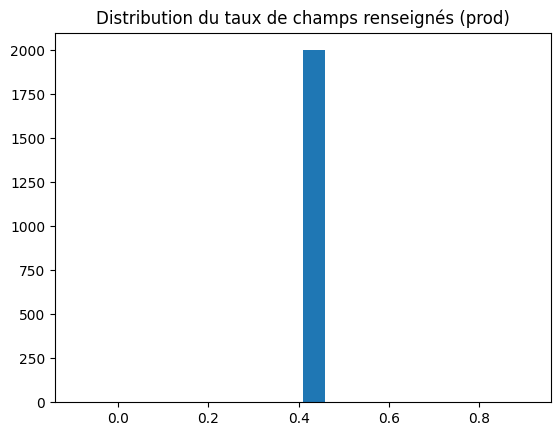

In [2]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

report_path = Path("outputs/monitoring/drift_report.json")
rep = json.loads(report_path.read_text(encoding="utf-8"))

print("Status:", rep["alerts"]["status"])
print("Warnings:", rep["alerts"]["n_warn"], "Critical:", rep["alerts"]["n_critical"])
display(pd.DataFrame(rep["alerts"]["items"]).head(20))

# Récupérer le tableau per-feature (ton script est robuste sur plusieurs schémas)
from monitoring.run_drift import _features_df_from_report  # noqa
df_feat = _features_df_from_report(rep)

# Top PSI
if "psi" in df_feat.columns:
    top = df_feat.dropna(subset=["psi"]).sort_values("psi", ascending=False).head(20)
    display(top[["feature", "psi"]])
    plt.figure()
    plt.barh(top["feature"][::-1], top["psi"][::-1])
    plt.title("Top 20 PSI (prod vs ref)")
    plt.show()

# 1) TOP missing delta
if "missing_rate_delta" in df_feat.columns:
    top_m = (
        df_feat.dropna(subset=["missing_rate_delta"])
        .assign(abs_delta=lambda d: d["missing_rate_delta"].abs())
        .sort_values("abs_delta", ascending=False)
        .head(20)
    )
    display(top_m[["feature", "missing_rate_delta", "ref_missing_rate", "prod_missing_rate"]])

    plt.figure()
    plt.barh(top_m["feature"][::-1], top_m["missing_rate_delta"][::-1])
    plt.title("Top 20 delta missing (prod - ref)")
    plt.show()

# 2) Diagnostic simple sur les données prod (doublons / complétude)
from monitoring.run_drift import load_prod_features, get_db_path

df_prod, meta = load_prod_features(get_db_path(), limit=2000)
print("Prod rows:", len(df_prod), "Distinct rows:", len(df_prod.drop_duplicates()))
print("Prod meta:", meta)

filled_ratio = df_prod.notna().mean(axis=1)
print("Filled ratio (mean):", filled_ratio.mean(), "min:", filled_ratio.min(), "max:", filled_ratio.max())

plt.figure()
plt.hist(filled_ratio, bins=20)
plt.title("Distribution du taux de champs renseignés (prod)")
plt.show()


In [3]:
# Résumé alerting (utile en soutenance)
alerts = rep.get("alerts", {})
print("Drift status:", alerts.get("status"))
print("n_warn:", alerts.get("n_warn"), "n_critical:", alerts.get("n_critical"))


Drift status: critical
n_warn: 747 n_critical: 817
